### Fault Tolerance using Persistence

In [8]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [9]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [10]:
# 2. Define steps
def step_1(state: CrashState):
    print("Executing Step 1")
    return {"step1": "Step 1 completed", "input": state['input']}

def step_2(state: CrashState):
    print("Step 2 hanging...")
    print("Now manually interrup from the notebook toolbar (STOP Button)")
    
    time.sleep(30) # Simulte long-running hang
    
    return {"step2": "Done"}

def step_3(state: CrashState):
    print("Step 3 is Executed")
    
    return {"done": True}

In [11]:
# 3. Build the Graph

graph = StateGraph(CrashState)
checkpointer = InMemorySaver()

graph.add_node("step_1", step_1)
graph.add_node("step_2", step_2)
graph.add_node("step_3", step_3)


# Add Edges
graph.add_edge(START, 'step_1')
graph.add_edge('step_1', 'step_2')
graph.add_edge('step_2', 'step_3')
graph.add_edge('step_3', END)


workflow = graph.compile(checkpointer=checkpointer)



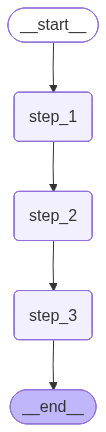

In [12]:
workflow

In [13]:

try:
    print("Running graph: Please manually interrupt during step: 2...")
    initial_state: CrashState = {
        "input": "start",
        "step1": "",
        "step2": "",
        "step3": "",
    }
    workflow.invoke(initial_state, config={"configurable": {"thread_id": "thread-1"}})
except KeyboardInterrupt:
    print("Kernel mannually interrrupted (Crash Simulated).")

Running graph: Please manually interrupt during step: 2...
Executing Step 1
Step 2 hanging...
Now manually interrup from the notebook toolbar (STOP Button)
Step 3 is Executed


In [14]:
workflow.get_state({"configurable": {"thread_id": 'thread-1'}})

StateSnapshot(values={'input': 'start', 'step1': 'Step 1 completed', 'step2': 'Done', 'step3': ''}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f176ef3-6680-62b4-8003-9e0b0946a23d'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-07-03T14:55:20.724344+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f176ef3-667c-6b3b-8002-a7f76fe9c408'}}, tasks=(), interrupts=())

In [16]:
# 6. Re-run to show fault-tolerant resume
resume_state: CrashState = {
	"input": "resume",
	"step1": "",
	"step2": "",
	"step3": "",
}
final_state = workflow.invoke(resume_state, config={"configurable": {"thread_id": "thread-1"}})
print("\n Final State: ", final_state)

Executing Step 1
Step 2 hanging...
Now manually interrup from the notebook toolbar (STOP Button)
Step 3 is Executed

 Final State:  {'input': 'resume', 'step1': 'Step 1 completed', 'step2': 'Done', 'step3': ''}
